In [ ]:
!pip install xgboost
!pip install flask
!pip install joblib

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving rainfall in india 1901-2015.xlsx to rainfall in india 1901-2015.xlsx


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

import joblib

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Rising water/rainfall in india 1901-2015.xlsx")

df.head()

,COUNTRY,STATE,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,India,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,India,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,India,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,India,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,India,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [ ]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   COUNTRY  4116 non-null   object 
 1   STATE    4116 non-null   object 
 2   YEAR     4116 non-null   int64  
 3   JAN      4112 non-null   float64
 4   FEB      4113 non-null   float64
 5   MAR      4110 non-null   float64
 6   APR      4112 non-null   float64
 7   MAY      4113 non-null   float64
 8   JUN      4111 non-null   float64
 9   JUL      4109 non-null   float64
 10  AUG      4112 non-null   float64
 11  SEP      4110 non-null   float64
 12  OCT      4109 non-null   float64
 13  NOV      4105 non-null   float64
 14  DEC      4106 non-null   float64
 15  ANNUAL   4090 non-null   float64
 16  Jan-Feb  4110 non-null   float64
 17  Mar-May  4107 non-null   float64
 18  Jun-Sep  4106 non-null   float64
 19  Oct-Dec  4103 non-null   float64
dtypes: float64(17), int64(1), object(2)
memory usage: 64

,0
COUNTRY,0
STATE,0
YEAR,0
JAN,4
FEB,3
MAR,6
APR,4
MAY,3
JUN,5
JUL,7


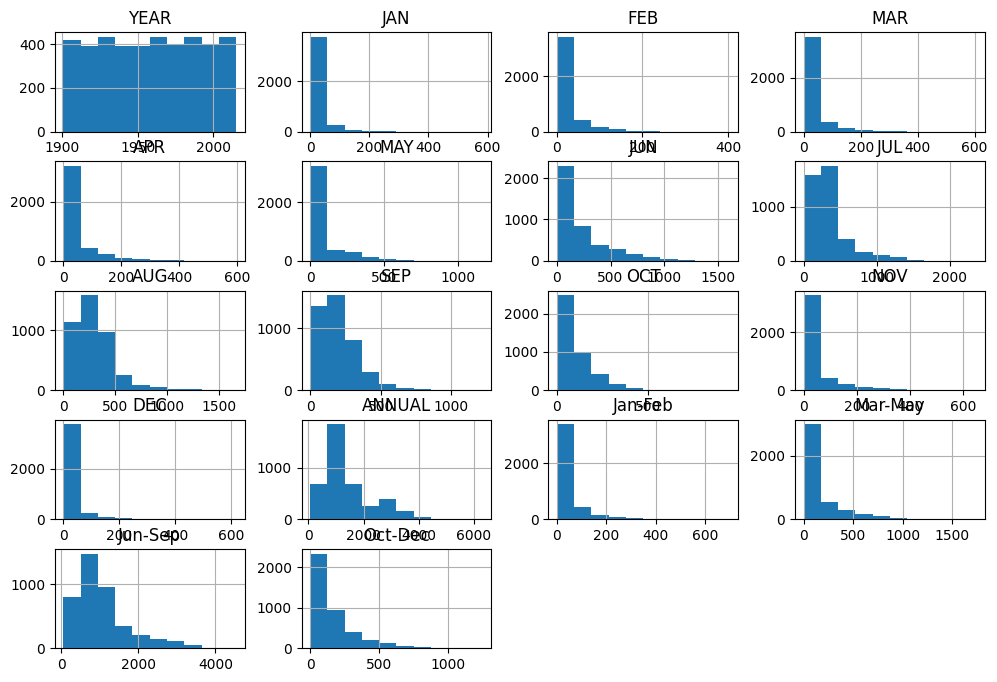

In [ ]:
df.hist(figsize=(12,8))
plt.show()

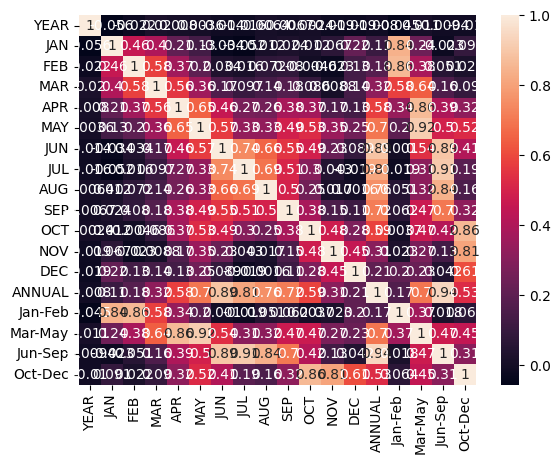

In [ ]:
numeric_df = df.drop(columns=['COUNTRY', 'STATE'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

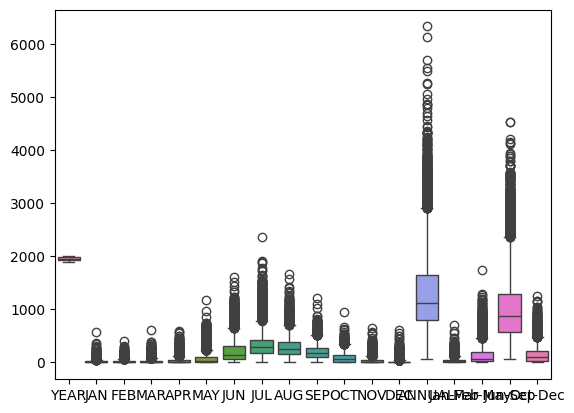

In [ ]:
sns.boxplot(data=df)
plt.show()

In [ ]:
df['flood'] = (df['ANNUAL'] > 2000).astype(int)
X = df.drop(columns=["flood", 'COUNTRY', 'STATE'])
y = df["flood"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [24]:
scaler=StandardScaler()

# Ensure X_train and X_test contain only numerical columns
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [25]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [26]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

RandomForestClassifier()

In [28]:
from sklearn.impute import SimpleImputer

knn=KNeighborsClassifier()

# Impute missing values in X_train before fitting
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

knn.fit(X_train_imputed,y_train)

KNeighborsClassifier()

In [29]:
xgb=XGBClassifier()

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
# Impute missing values in X_test using the same imputer fitted on X_train
X_test_imputed = imputer.transform(X_test)

for model in [dt,rf,knn,xgb]:

    # Use X_test_imputed for all models for consistency, as knn requires it
    pred=model.predict(X_test_imputed)

    print(type(model).__name__)

    print(accuracy_score(y_test,pred))

DecisionTreeClassifier
1.0
RandomForestClassifier
1.0
KNeighborsClassifier
0.991504854368932
XGBClassifier
0.9987864077669902


In [32]:
joblib.dump(xgb,"floods.save")

joblib.dump(scaler,"scaler.save")

['scaler.save']

In [33]:
files.download("floods.save")

files.download("scaler.save")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>